# Прогнозирование оттока клиентов телеком-компании

**Описание проекта:**   
Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах

**Цель исследования:**   
Обучить на предоставленных данных модель для прогноза оттока клиентов.   

**Описание данных:**   
Оператор предоставляет два основных типа услуг:   
Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.  
Интернет. Подключение может быть двух типов: через телефонную линию (DSL, от англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (Fiber optic).  
Также доступны такие услуги:  
Интернет-безопасность: антивирус (DeviceProtection) и блокировка небезопасных сайтов (OnlineSecurity);  
Выделенная линия технической поддержки (TechSupport);  
Облачное хранилище файлов для резервного копирования данных (OnlineBackup);  
Стриминговое телевидение (StreamingTV) и каталог фильмов (StreamingMovies).  
Клиенты могут платить за услуги каждый месяц или заключить договор на 1–2 года. Возможно оплатить счёт разными способами, а также получить электронный чек.  
4 датасета с данными по клиентам, договорам. Около 5-7 тысяч строк в каждом датасете


**Ход исследования:**
- [1. Загрузка данных](#загрузка)
- [2. Исследовательский анализ и предобработка данных](#анализ1)
- [3. Объединение данных](#объединение)
- [4. Исследовательский анализ и предобработка данных объединённого датафрейма](#анализ2)
- [5. Подготовка данных](#подготовка)
- [6. Обучение моделей машинного обучения](#обучение)
- [7. Выбор лучшей модели](#выбор)
- [8. Общий вывод и рекомендации заказчику](#вывод)
 

**Общий вывод:**   
Были обучены три модели - SVC, RandomForestClassifier и Catboost. По итогам лучшей моделью становится Catboost. Результат Catboost ROC_AUC на тестовой выборке: 0.881. В 88,1% модель присвоит более высокую вероятность ухода клиенту, который реально уйдет. В 81,1% случаев модель классифицировала клиентов (и уходящих, и остающихся) правильно. В 44,2% случаев, когда модель предсказала уходящих клиентов, клиенты реально ушли. В 79,6% случаев модель правильно предсказала уходящих клиентов.  
Клиенту посоветуем обращать внимание на срок договора, тип договора, и на сумму, которую клиент платит - чем она выше, тем больше шансов, что клиент "сбежит"

<a id="загрузка"></a> 
# 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from phik.report import plot_correlation_matrix
from phik import report

from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (OneHotEncoder, 
                                    StandardScaler, 
                                    MinMaxScaler
                                  )

from sklearn.model_selection import (GridSearchCV,
                                    RandomizedSearchCV, 
                                    StratifiedKFold
                                    )
from sklearn.metrics import (roc_auc_score, 
                             accuracy_score, 
                             confusion_matrix,
                             precision_score, 
                             recall_score
                            )
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier, cv, Pool

RANDOM_STATE = 151225
TEST_SIZE = 0.25

pd.set_option('display.max_colwidth', 200)

Загрузим все 4 датасета, проверим, что всё загрузилось и открылось

In [2]:
# 1-ый датасет с контрактами
try:
    df_cont = pd.read_csv('/contract_new.csv')
except:
    df_cont = pd.read_csv('https://code.s3.yandex.net/datasets/contract_new.csv')
display(df_cont.head(3))
display(df_cont.shape)

# 2-ой датасет с данными абонента
try:
    df_pers = pd.read_csv('/personal_new.csv')
except:
    df_pers = pd.read_csv('https://code.s3.yandex.net/datasets/personal_new.csv')
display(df_pers.head(3))
display(df_pers.shape)

# 3-ий датасет с договорами по интернету
try:
    df_int = pd.read_csv('/internet_new.csv')
except:
    df_int = pd.read_csv('https://code.s3.yandex.net/datasets/internet_new.csv')
display(df_int.head(3))
display(df_int.shape)

# 4-ый датасет с договорами по телефонии
try:
    df_phone = pd.read_csv('/phone_new.csv')
except:
    df_phone = pd.read_csv('https://code.s3.yandex.net/datasets/phone_new.csv')
display(df_phone.head(3))
display(df_phone.shape)

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17


(7043, 8)

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No


(7043, 5)

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No


(5517, 8)

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No


(6361, 2)

Создадим функцию для первичного осмотра данных в датасете

In [3]:
def opening(df):
    print('ПЕРВЫЕ ПЯТЬ СТРОК')
    display(df.head())
    
    print('ИНФОРМАЦИЯ О ДАТАСЕТЕ')
    df.info(), print('\n')
    
    
    print('КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ')
    print(df.isna().sum())
    
    print('КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %')
    print(df.isna().sum() / df.shape[0] * 100, '\n')
    
    print('ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ (В СЛУЧАЕ ОТСУТСТВИЯ - КАТЕГОРИАЛЬНЫХ)')
    print(df.describe(), '\n')

    print('УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ')
    cat_cols = df.select_dtypes(include=['category', 'object'])
    for i in cat_cols:
        print(f"{i}: {df[i].nunique()} уникальные значения - {df[i].unique()}")
    print('\n')
    
    print('КОЛИЧЕСТВО ДУБЛИКАТОВ')
    print(df.duplicated().sum())
    
    print('РАСПРЕДЕЛЕНИЕ ДАННЫХ КОЛИЧЕСТВЕННЫХ СТОЛБЦОВ')
    try:
        df.hist(figsize=(15,10), bins=20)
    except ValueError:
        pass

ПЕРВЫЕ ПЯТЬ СТРОК


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64
КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %
customerID          0.0
BeginDate           0.0
EndDate             0.0
Type              

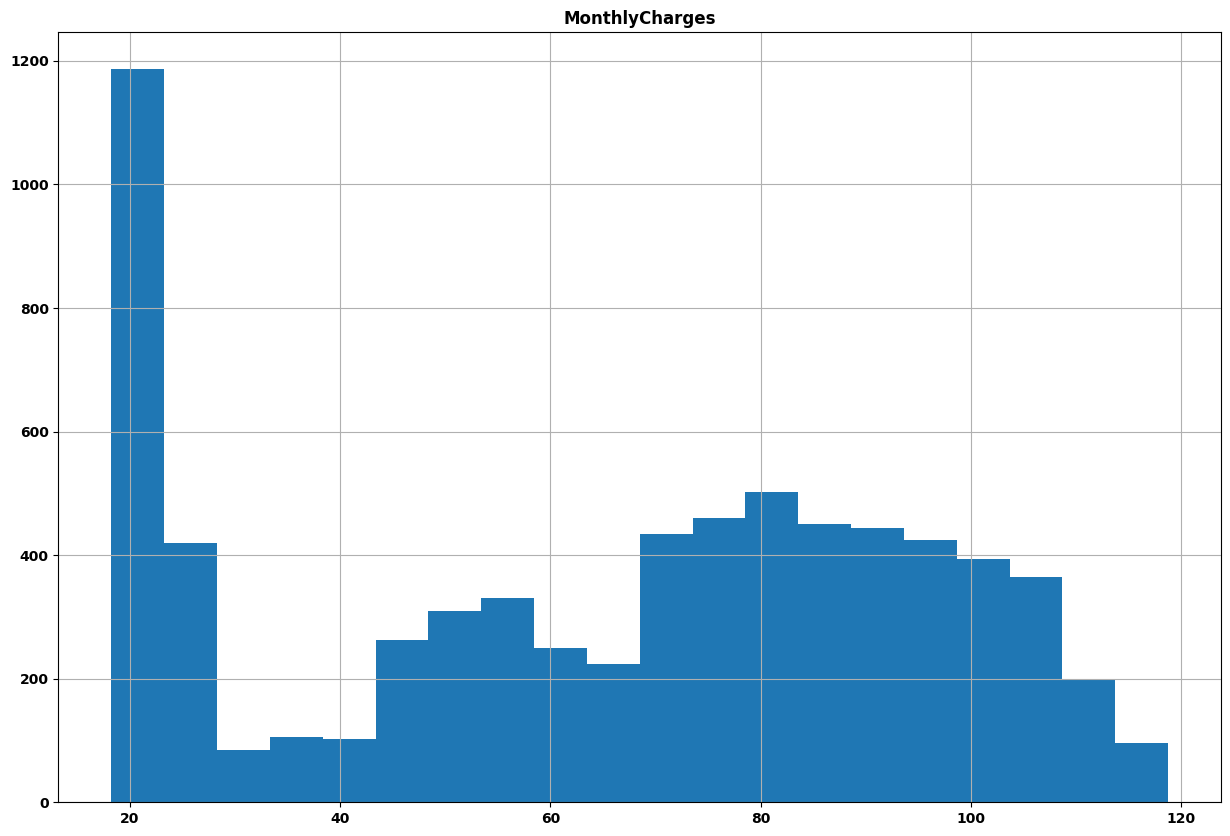

In [4]:
opening(df_cont)

ПЕРВЫЕ ПЯТЬ СТРОК


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64
КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %
customerID       0.0
gender           0.0
SeniorCitizen    0.0
Partner          0.0
Dependents       0.0
dtype: float64 

ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ (В СЛУЧАЕ ОТСУТСТВИЯ - КАТЕГОРИАЛЬНЫХ)
       SeniorCitizen
count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%      

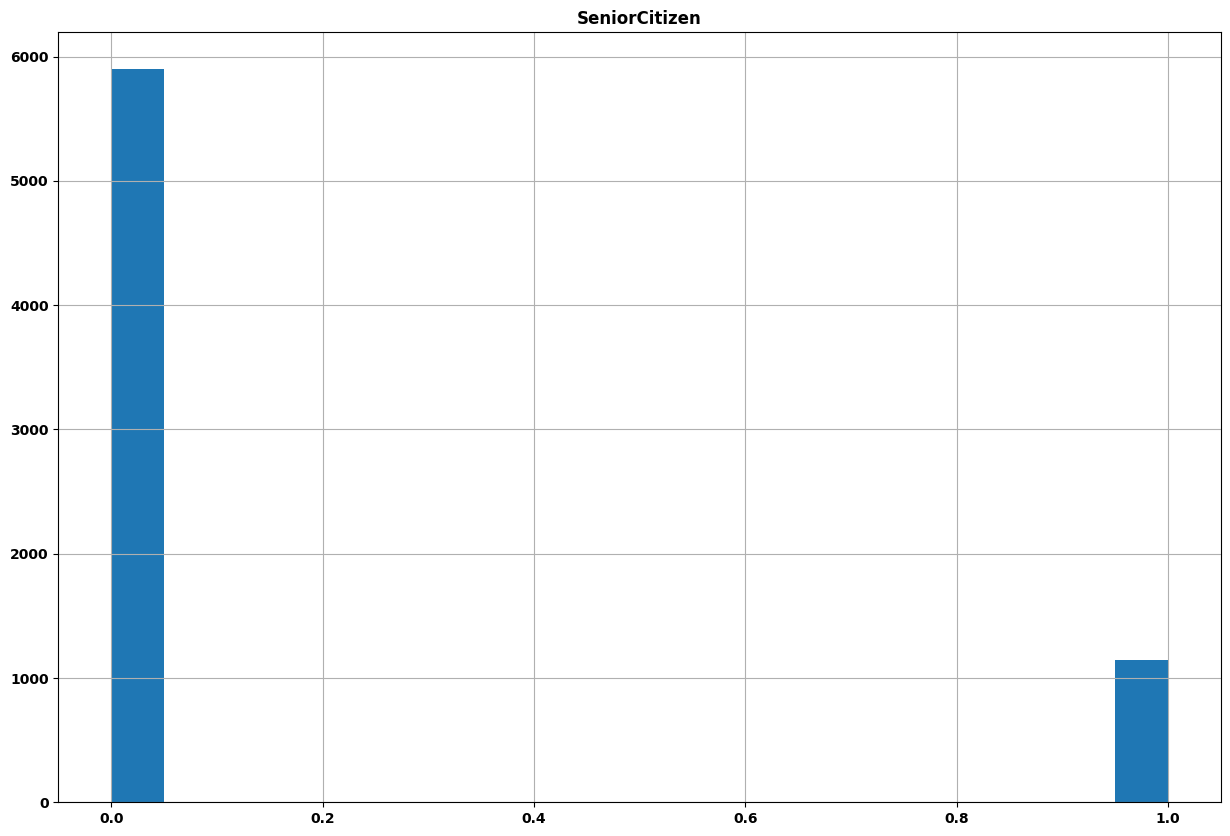

In [5]:
opening(df_pers)

In [6]:
opening(df_int)

ПЕРВЫЕ ПЯТЬ СТРОК


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64
КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %
customerID          0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection

In [7]:
opening(df_phone)

ПЕРВЫЕ ПЯТЬ СТРОК


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
customerID       0
MultipleLines    0
dtype: int64
КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %
customerID       0.0
MultipleLines    0.0
dtype: float64 

ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ (В СЛУЧАЕ ОТСУТСТВИЯ - КАТЕГОРИАЛЬНЫХ)
        customerID MultipleLines
count         6361          6361
unique        6361             2
top     5575-GNVDE            No
freq             1          3390 

УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ
customerID: 6361 уникальные значения - ['5575-GNVDE' '3668-QPYBK' '9237-HQITU' ... '2234-XADUH' '8361-LTMKD'
 '3186-AJIEK']
MultipleLines: 2 уникальные значения - ['No' 'Yes']


КОЛИЧЕСТВО ДУБЛИКАТОВ
0
Р

**Вывод по разделу:**
- 4 датасета с данными по клиентам и договорам по телекоммуникаям (интернет + телефония). В датасетах не более 7000 строк
- необходимо провести предобработку данных (привести к нижнему регистру названия столбцов, сделать более удобный вид для различных значений для дальнейшей работы (убрать пробелы, заглавные буквы)
- необходимо поменять тип данных у некоторых столбцов
- дубликатов нет, пропущенных значений нет

<a id="анализ1"></a> 
# 2. Исследовательский анализ и предобработка данных

Обработаем 1-ый датасет. Приведем названия колонок к нижнему регистру, добавим нижний прочерк между словами.
Приведем оба столбца с датами из типа данных object к datetime.
В end_date есть значения 'No', их заменим на пропуски, так как окончания договора еще нет.

In [8]:
df_cont = df_cont.rename(columns={'customerID':'customer_id', 'BeginDate':'begin_date', 'EndDate':'end_date', 'Type':'type', \
                                 'PaperlessBilling':'paperless_billing', 'PaymentMethod':'payment_method', \
                                 'MonthlyCharges':'monthly_charges', 'TotalCharges':'total_charges'})

df_cont['begin_date'] = pd.to_datetime(df_cont['begin_date'])

df_cont['end_date'] = df_cont['end_date'].replace('No', np.nan)
df_cont['end_date'] = pd.to_datetime(df_cont['end_date'])

total_charges нужно привести к типу данных float64. Для этого нам нужно сначала заменить пустые клетки на NaN

In [9]:
df_cont[df_cont['begin_date'] == '2020-02-01']

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,


In [10]:
df_cont['total_charges'] = df_cont['total_charges'].replace (' ', np.nan).astype('float64')

df_cont[~df_cont['total_charges'].notna()]

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,NaN
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,NaN
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,NaN
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,NaN
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,NaN
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,NaN
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,NaN
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,NaN


Появилось 11 пропусков в этом столбце. Эти данные появились у клиентов, кто только-только заключил договора. И данные в total_charges еще не внеслись. Там почти точно будет стоять число из monthly_charges (или очень близкое к нему). Вставим вместо NaN значения из месячной стоимости услуг

In [11]:
df_cont.loc[df_cont['total_charges'].isna(), 'total_charges'] = df_cont.loc[df_cont['total_charges'].isna(), 'monthly_charges']

Добавим столбец churn на основании столбца end_date: если контракт закончился - ставим 1, если нет - 0.  
ЭТОТ ЖЕ СТОЛБЕЦ МЫ БУДЕМ ИСПОЛЬЗОВАТЬ КАК ЦЕЛЕВОЙ ПРИЗНАК! При этом столбец end_date в обучение не войдет. Для исследовательского анализа данных передаем этот столбец в значения Yes и No

ПЕРВЫЕ ПЯТЬ СТРОК


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,No
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,No
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,1960.60,No
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,No


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1101 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   churn              7043 non-null   object        
dtypes: datetime64[ns](2), float64(2), object(5)
memory usage: 495.3+ KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
customer_id             0
begin_date              0
end_date             5942
type                    0
paperless_billing       0
payment_method          0
mont

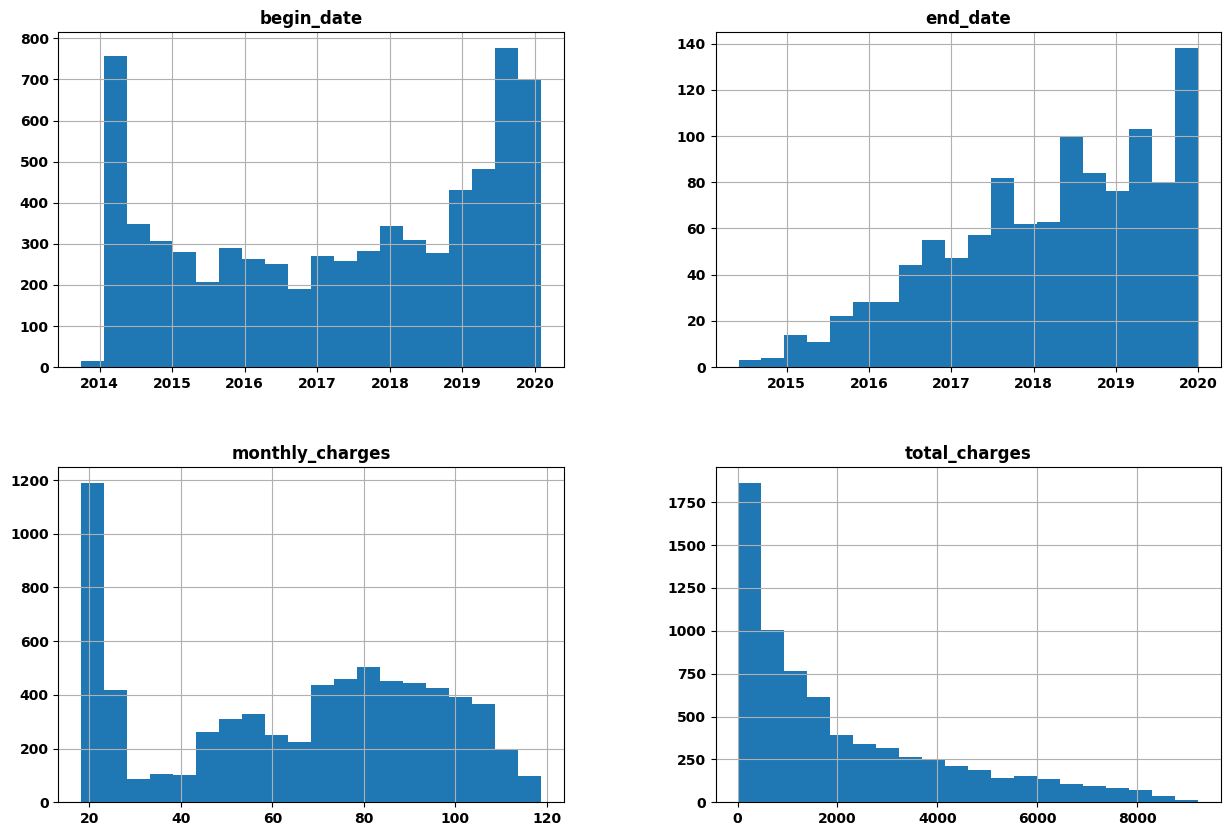

In [12]:
df_cont['churn'] = df_cont['end_date'].notna().astype('int').map({0:'No', 1:'Yes'})

opening(df_cont)

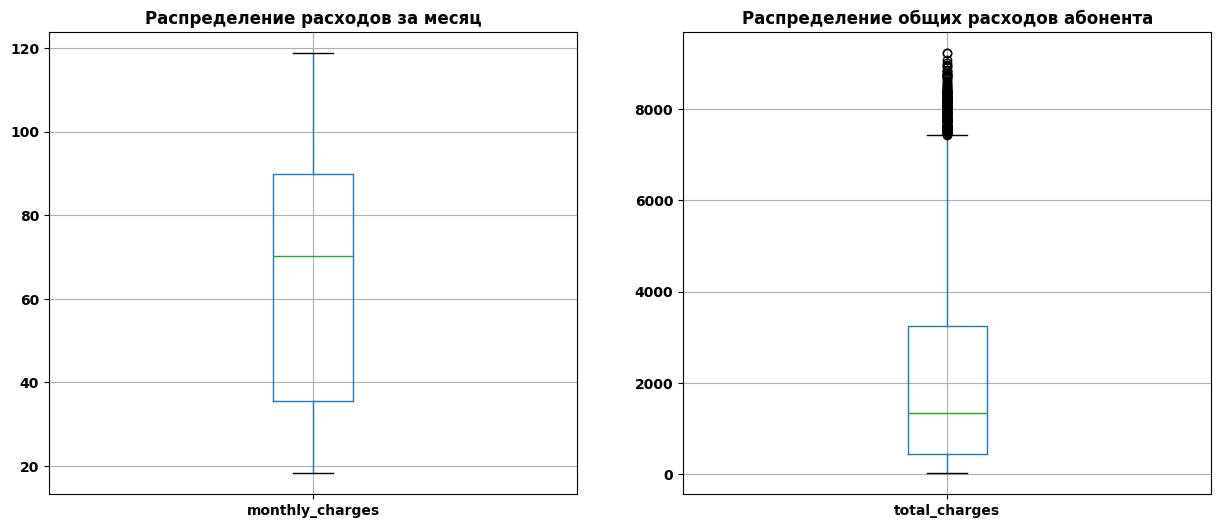

In [13]:
fig1, axes = plt.subplots(1, 2, figsize=(15,6))

df_cont.boxplot(column = 'monthly_charges', ax=axes[0])
axes[0].set_title('Распределение расходов за месяц')

df_cont.boxplot(column = 'total_charges', ax=axes[1])
axes[1].set_title('Распределение общих расходов абонента');

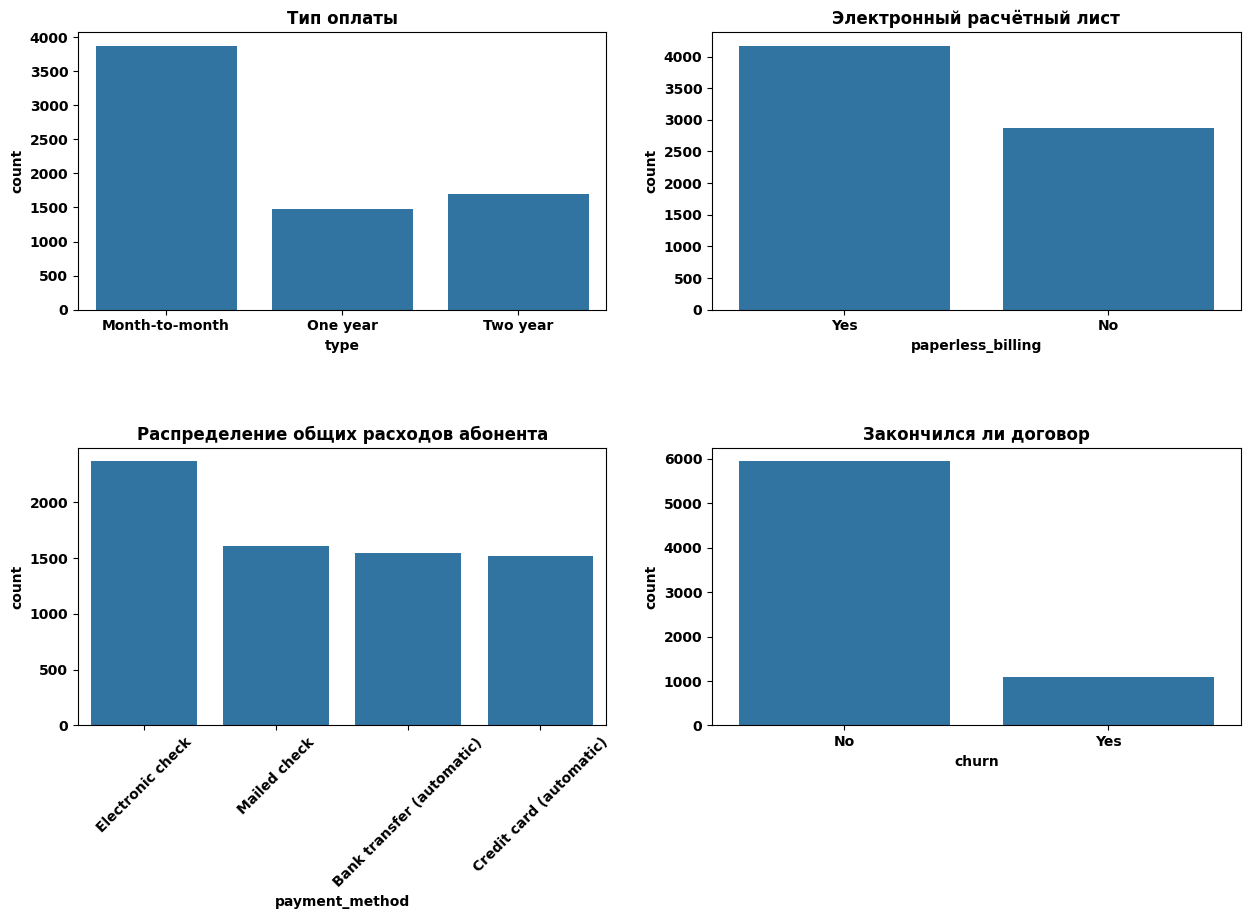

In [14]:
kat1, axes = plt.subplots(2, 2, figsize=(15,9))
kat1.subplots_adjust(hspace = 0.5)

sns.countplot(data = df_cont, x = 'type', ax=axes[0, 0])
axes[0, 0].set_title('Тип оплаты')

sns.countplot(data = df_cont, x = 'paperless_billing', ax=axes[0, 1])
axes[0, 1].set_title('Электронный расчётный лист')

sns.countplot(data = df_cont, x = 'payment_method', ax=axes[1, 0])
axes[1, 0].set_title('Распределение общих расходов абонента')
axes[1, 0].tick_params(axis='x', labelrotation=45)

sns.countplot(data = df_cont, x = 'churn', ax=axes[1, 1])
axes[1, 1].set_title('Закончился ли договор');

Преобразовали 1-ый датасет для дальнейшей работы, удалили 11 строк, посмотрели на распределение (числовых и категориальных столбцов). Добавили новый столбец churn на основании end_date. Есть выбросы в общих расходах абонента, но они не сильно выделяющиеся их приличное количество, выбросить их не можем

Во втором датасете так же меняем названия столбцов. Меняем тип данных senior_citizen на object, так как это категориальная переменная. Меняем на Yes и No

In [15]:
df_pers = df_pers.rename(columns={'customerID':'customer_id', 'SeniorCitizen':'senior_citizen', 'Partner':'partner', \
                                  'Dependents':'dependents'})

df_pers['senior_citizen'] = df_pers['senior_citizen'].astype('object')
df_pers['senior_citizen'] = df_pers['senior_citizen'].map({0:'No', 1:'Yes'})

opening(df_pers)

ПЕРВЫЕ ПЯТЬ СТРОК


,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,No,Yes,No
1,5575-GNVDE,Male,No,No,No
2,3668-QPYBK,Male,No,No,No
3,7795-CFOCW,Male,No,No,No
4,9237-HQITU,Female,No,No,No


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   object
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
customer_id       0
gender            0
senior_citizen    0
partner           0
dependents        0
dtype: int64
КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %
customer_id       0.0
gender            0.0
senior_citizen    0.0
partner           0.0
dependents        0.0
dtype: float64 

ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ (В СЛУЧАЕ ОТСУТСТВИЯ - КАТЕГОРИАЛЬНЫХ)
       customer_id gender senior_citizen partner dependents
count         7043   7043           7043    7043       7043
unique        7043      2    

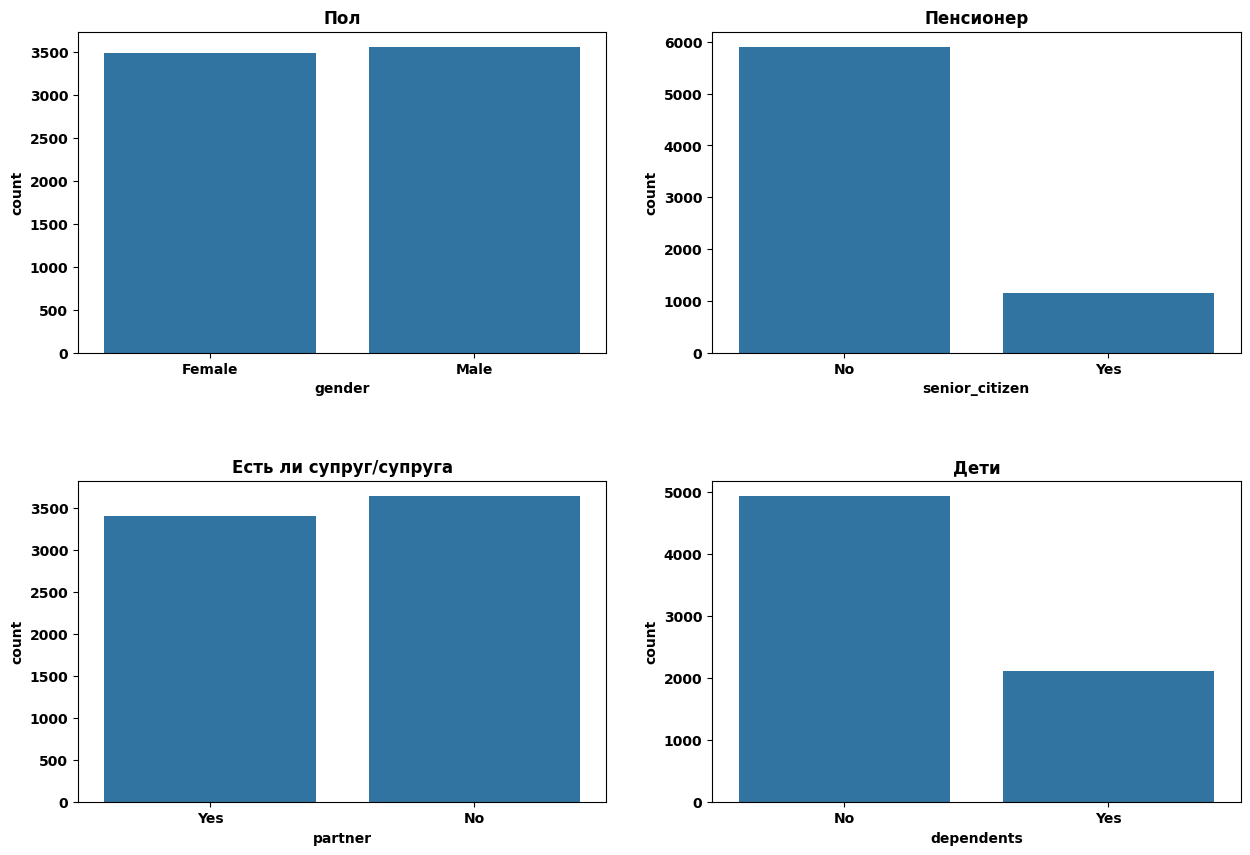

In [16]:
kat2, axes = plt.subplots(2, 2, figsize=(15,10))
kat2.subplots_adjust(hspace=0.4)

sns.countplot(data = df_pers, x = 'gender', ax=axes[0, 0])
axes[0, 0].set_title('Пол')

sns.countplot(data = df_pers, x = 'senior_citizen', ax=axes[0, 1])
axes[0, 1].set_title('Пенсионер')

sns.countplot(data = df_pers, x = 'partner', ax=axes[1, 0])
axes[1, 0].set_title('Есть ли супруг/супруга')

sns.countplot(data = df_pers, x = 'dependents', ax=axes[1, 1])
axes[1, 1].set_title('Дети');

Во втором датасете поменяли тип данных, значения на yes, no, посмотрели на распределение. Ничего странного нет

В 3-ем датасете меняем названия столбцов

In [17]:
df_int = df_int.rename(columns={'customerID':'customer_id', 'InternetService':'internet_service', \
                                'OnlineSecurity':'online_security', 'OnlineBackup':'online_backup', \
                                 'DeviceProtection':'device_protection', 'TechSupport':'tech_support', \
                                 'StreamingTV':'streaming_tv', 'StreamingMovies':'streaming_movies'})


opening(df_int)

ПЕРВЫЕ ПЯТЬ СТРОК


,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
customer_id          0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
dtype: int64
КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %
customer_id          0.0
internet_service     0.0
online_security      0.0
online_backup      

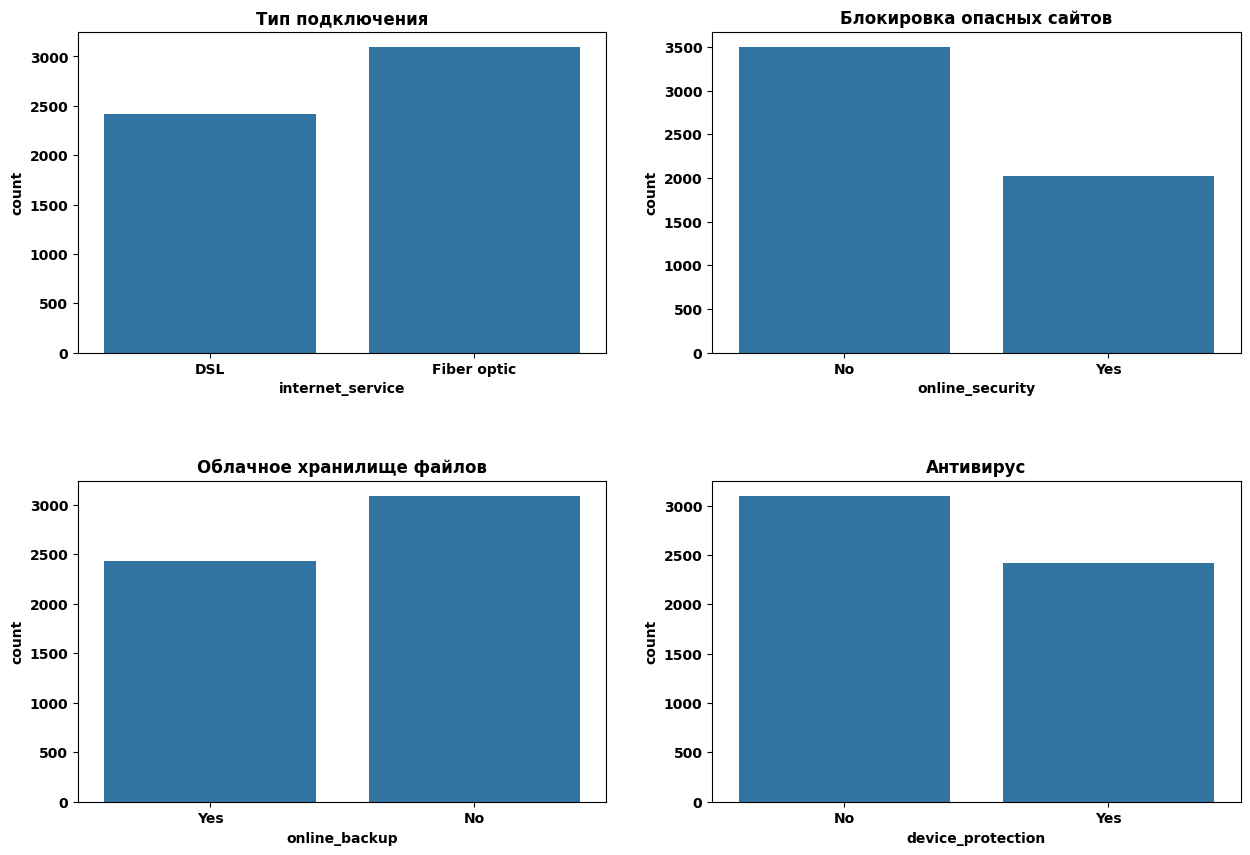

In [18]:
kat3_1, axes = plt.subplots(2, 2, figsize=(15,10))
kat3_1.subplots_adjust(hspace=0.4)

sns.countplot(data = df_int, x = 'internet_service', ax=axes[0, 0])
axes[0, 0].set_title('Тип подключения')

sns.countplot(data = df_int, x = 'online_security', ax=axes[0, 1])
axes[0, 1].set_title('Блокировка опасных сайтов')

sns.countplot(data = df_int, x = 'online_backup', ax=axes[1, 0])
axes[1, 0].set_title('Облачное хранилище файлов')

sns.countplot(data = df_int, x = 'device_protection', ax=axes[1, 1])
axes[1, 1].set_title('Антивирус');

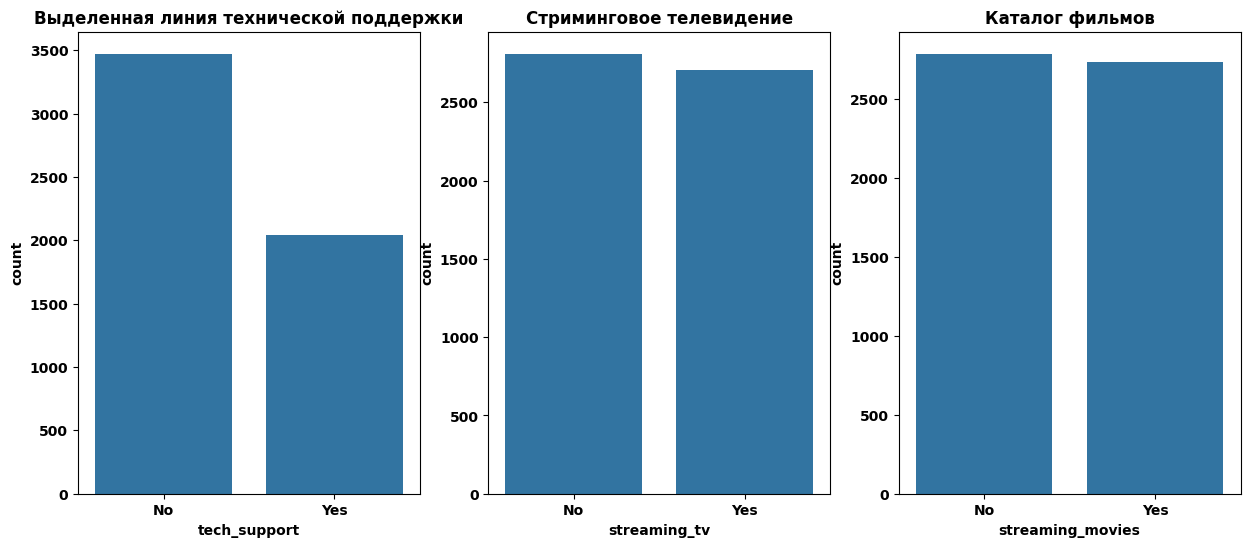

In [19]:
kat3_2, axes = plt.subplots(1, 3, figsize=(15,6))

sns.countplot(data = df_int, x = 'tech_support', ax=axes[0])
axes[0].set_title('Выделенная линия технической поддержки')

sns.countplot(data = df_int, x = 'streaming_tv', ax=axes[1])
axes[1].set_title('Стриминговое телевидение')

sns.countplot(data = df_int, x = 'streaming_movies', ax=axes[2])
axes[2].set_title('Каталог фильмов');

В третьем датасете только поменяли названия колонок и посмотрели на категориальные данные, на их распределение, ничего необычного нет

В 4-ом датасете меняем названия столбцов

In [20]:
df_phone = df_phone.rename(columns={'customerID':'customer_id', 'MultipleLines':'multiple_lines'})

opening(df_phone)

ПЕРВЫЕ ПЯТЬ СТРОК


,customer_id,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
customer_id       0
multiple_lines    0
dtype: int64
КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ, %
customer_id       0.0
multiple_lines    0.0
dtype: float64 

ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ (В СЛУЧАЕ ОТСУТСТВИЯ - КАТЕГОРИАЛЬНЫХ)
       customer_id multiple_lines
count         6361           6361
unique        6361              2
top     5575-GNVDE             No
freq             1           3390 

УНИКАЛЬНЫЕ ЗНАЧЕНИЯ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ
customer_id: 6361 уникальные значения - ['5575-GNVDE' '3668-QPYBK' '9237-HQITU' ... '2234-XADUH' '8361-LTMKD'
 '3186-AJIEK']
multiple_lines: 2 уникальные значения - ['No' 'Yes']


КОЛИЧЕСТВО

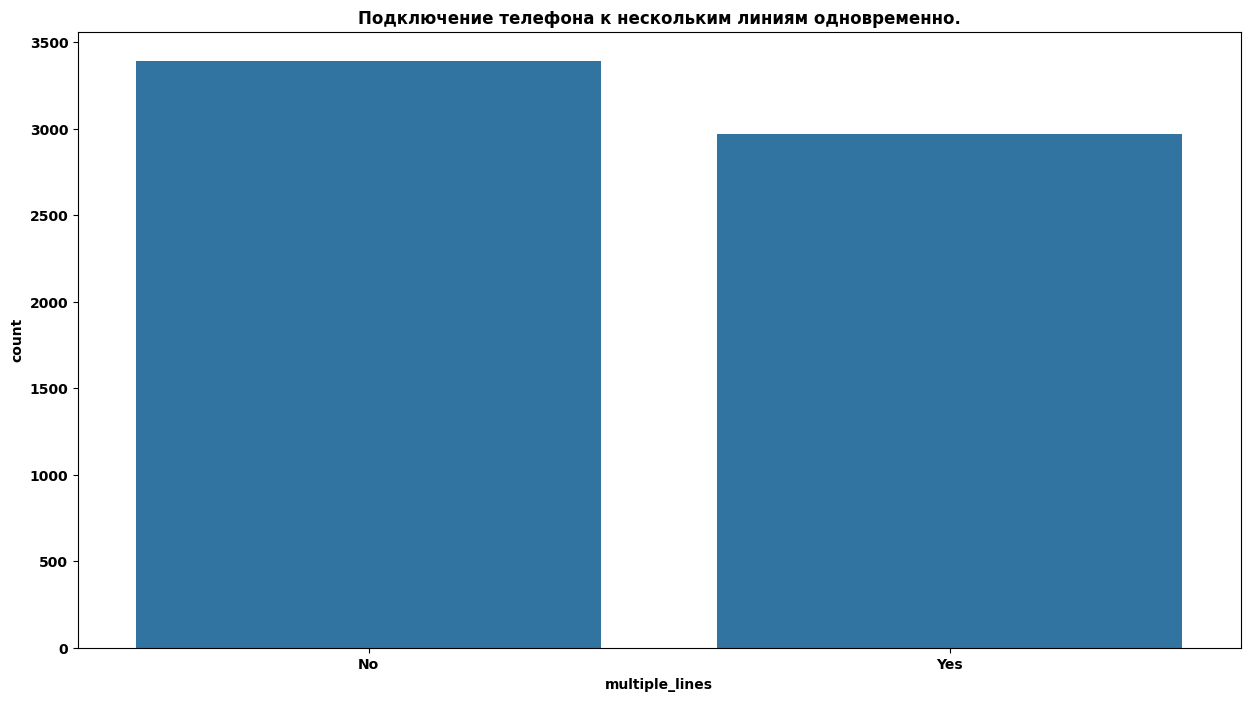

In [21]:
plt.figure(figsize=(15,8))
sns.countplot(data = df_phone, x = 'multiple_lines')
plt.title('Подключение телефона к нескольким линиям одновременно.');

В 4-ом датасете тоже только поменяли названия колонок и посмотрели на распределение единственной колонки с категориальными данными

**Выводы по разделу:**
- Во всех четырех датасетах изменили названия колонок (привели к нижнему регистру, поставили нижнее подчеркивание между словами)
- добавили новый столбец churn (будет целевой признак)
- Поменяли где необходимо тип данных и значения в таблицах
- Удалили несколько строк, где нет данных
- Посмотрели на распределение категориальных и числовых переменных. Ничего необычного мы не увидели
- В обучение не войдет столбец end_date (так как мы сделали на его основе бинарный столбец churn)

<a id="объединение"></a> 
# 3. Объединение данных

Теперь займемся присоединением таблиц. Первая таблица у нас главная, к ней и будем присоединять. Ключ - customer_id

In [22]:
display(df_cont.shape)
display(df_pers.shape)
display(df_int.shape)
display(df_phone.shape)

(7043, 9)

(7043, 5)

(5517, 8)

(6361, 2)

In [23]:
df = (df_cont
    .merge(df_pers, on='customer_id', how='left')
    .merge(df_int, on='customer_id', how='left')
    .merge(df_phone, on='customer_id', how='left')
)

In [24]:
display(df.head(3))
display(df.shape)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,churn,gender,...,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,No,Female,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84,No,Male,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,No,Male,...,No,No,DSL,Yes,Yes,No,No,No,No,No


(7043, 21)

In [25]:
df.isna().sum()

customer_id             0
begin_date              0
end_date             5942
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
churn                   0
gender                  0
senior_citizen          0
partner                 0
dependents              0
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
multiple_lines        682
dtype: int64

**ВЫВОДЫ ПО РАЗДЕЛУ:**
- Объединили 4 датасета в один по ключу customer_id, присоединили всё к первой таблице. Итого у нас 7032 строки и 21 столбец
- end_date мы при подготовке данных уберем (мы сделали churn, который и будет целевым призраком). И получилось приличное количество пропусков. С ними дальше будем работать

<a id="анализ2"></a> 
# 4. Исследовательский анализ и предобработка данных объединённого датафрейма

Создадим столбец contract_duration, в котором отобразим количество месяцев от начала договора по текущую дату (1 февраля 2020 года), если договор не окончен. Или же по дату end_date. Столбец begin_date теперь тоже не войдет в обучение.

Убираем столбцы begin_date и end_date из таблицы, они для обучения нам не нужны

Заменим пропуски в таблице на значение not_used. Мы не можем заменить их на No, потому что:
1) В случае с интернетом No - это услуги, которые клиент целенаправленно не выбрал, хотя интернет есть  
2) В случае с телефоном No - это подключенная телефония с одной линией  
У нас клиенты с пропусками - это вообще клиент без данной услуги. Так что ставим 'not_used'

столбец customer_id делаем индексом

In [26]:
date_now = pd.Timestamp('2020-02-01')
final_date = df['end_date'].fillna(date_now)

df['contract_duration'] = (final_date - df['begin_date']).dt.days

df = df.drop(['begin_date', 'end_date'], axis=1)

df['internet_service'] = df['internet_service'].fillna('not_used')
df['online_security'] = df['online_security'].fillna('not_used')
df['online_backup'] = df['online_backup'].fillna('not_used')
df['device_protection'] = df['device_protection'].fillna('not_used')
df['tech_support'] = df['tech_support'].fillna('not_used')
df['streaming_tv'] = df['streaming_tv'].fillna('not_used')
df['streaming_movies'] = df['streaming_movies'].fillna('not_used')
df['multiple_lines'] = df['multiple_lines'].fillna('not_used')

df = df.set_index('customer_id')

df.head(3)

,type,paperless_billing,payment_method,monthly_charges,total_charges,churn,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,contract_duration
customer_id,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,31.04,No,Female,No,Yes,No,DSL,No,Yes,No,No,No,No,not_used,31
5575-GNVDE,One year,No,Mailed check,56.95,2071.84,No,Male,No,No,No,DSL,Yes,No,Yes,No,No,No,No,1036
3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,226.17,No,Male,No,No,No,DSL,Yes,Yes,No,No,No,No,No,123


у нас теперь 4 столбца с числовыми признаками, посмотрим на их распеределение. В monthly_charges и total_charges 
изменений нет. Добавились новый столбец contract_duration, по распределению всё хорошо, ничего необычного нет

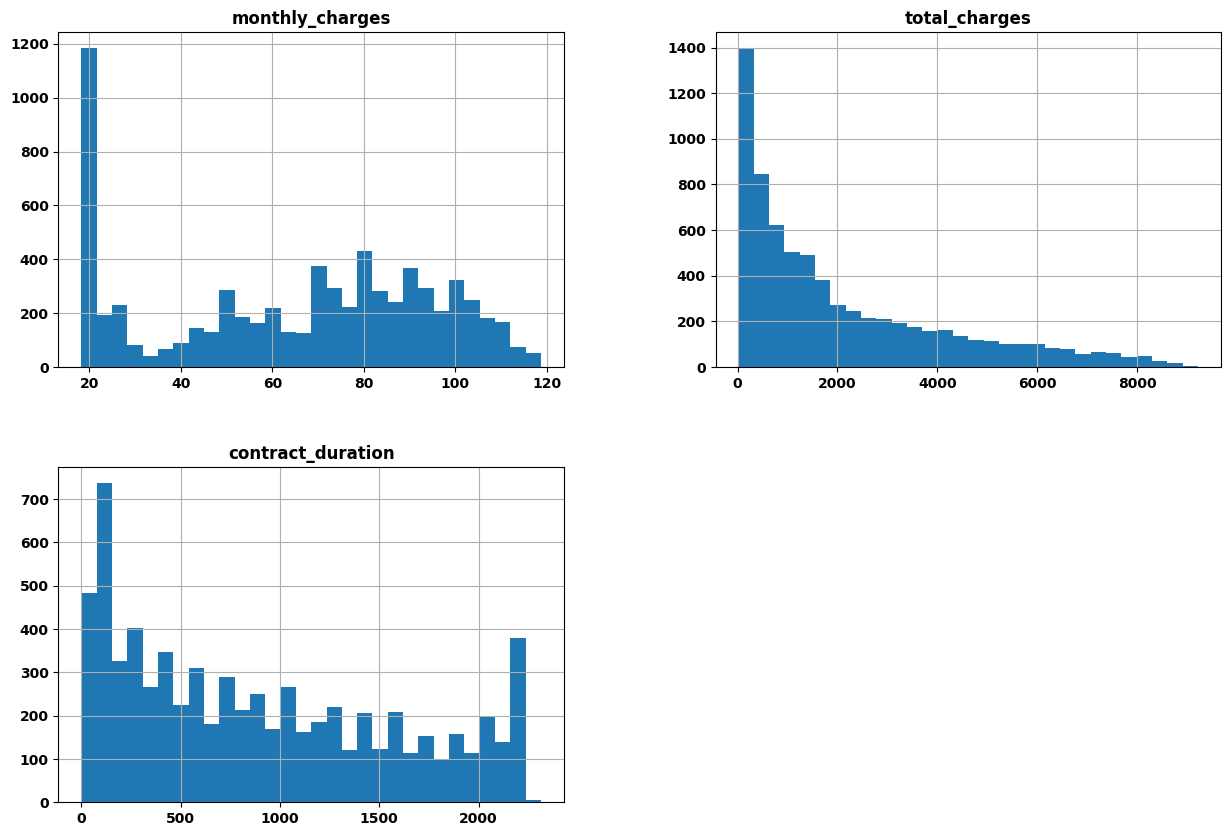

In [27]:
df.hist(figsize=(15,10), bins=30);

Посмотрим, не изменилось ли ничего с категориальными переменными, перед тем как дальше работать с данными

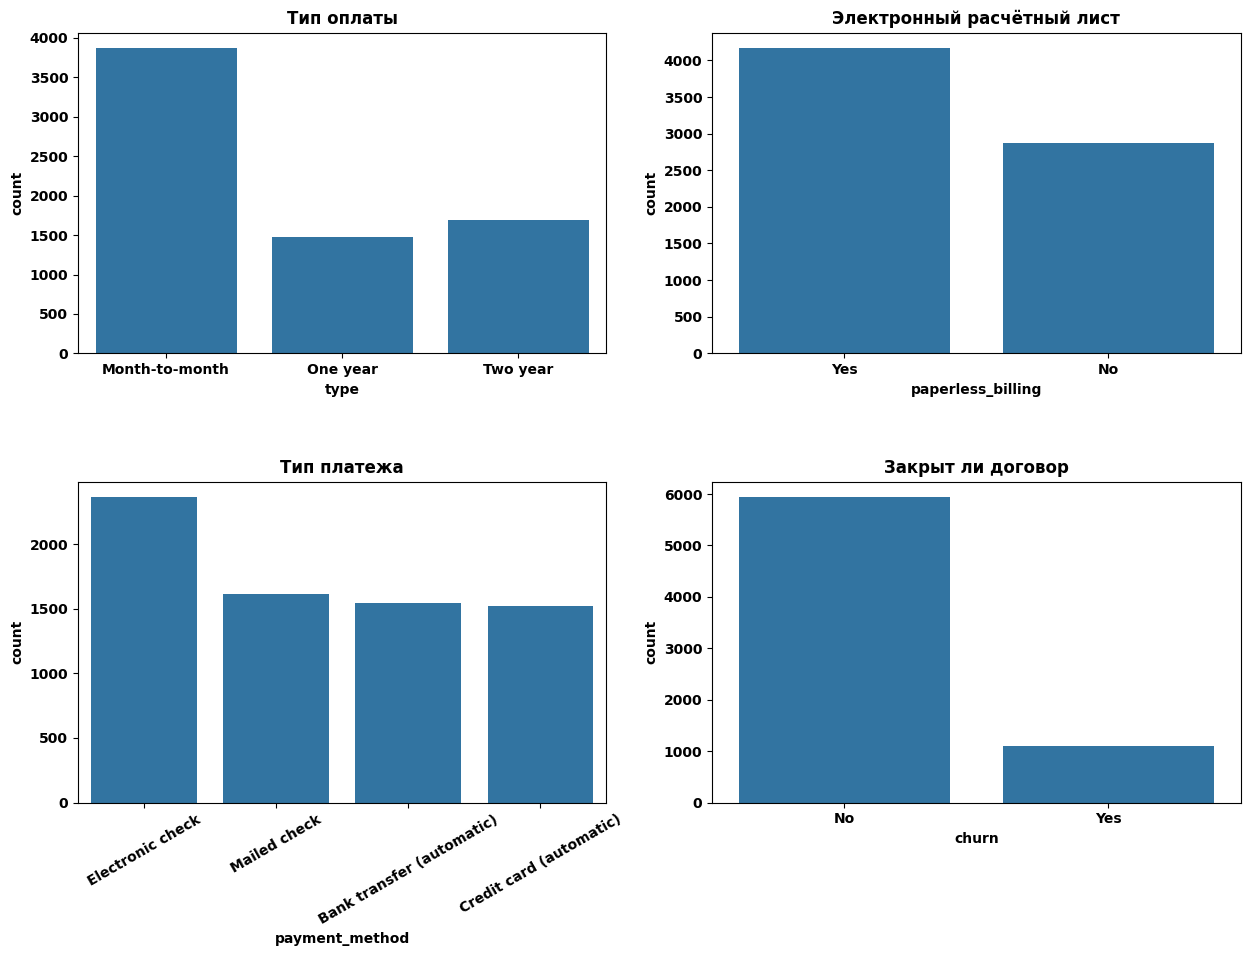

In [28]:
kat_df_1, axes = plt.subplots(2, 2, figsize=(15,10))
kat_df_1.subplots_adjust(hspace=0.4)

sns.countplot(data = df, x = 'type', ax=axes[0, 0])
axes[0, 0].set_title('Тип оплаты')

sns.countplot(data = df, x = 'paperless_billing', ax=axes[0, 1])
axes[0, 1].set_title('Электронный расчётный лист')

sns.countplot(data = df, x = 'payment_method', ax=axes[1, 0])
axes[1, 0].set_title('Тип платежа')
axes[1, 0].tick_params(axis='x', labelrotation=30)

sns.countplot(data = df, x = 'churn', ax=axes[1, 1])
axes[1, 1].set_title('Закрыт ли договор');

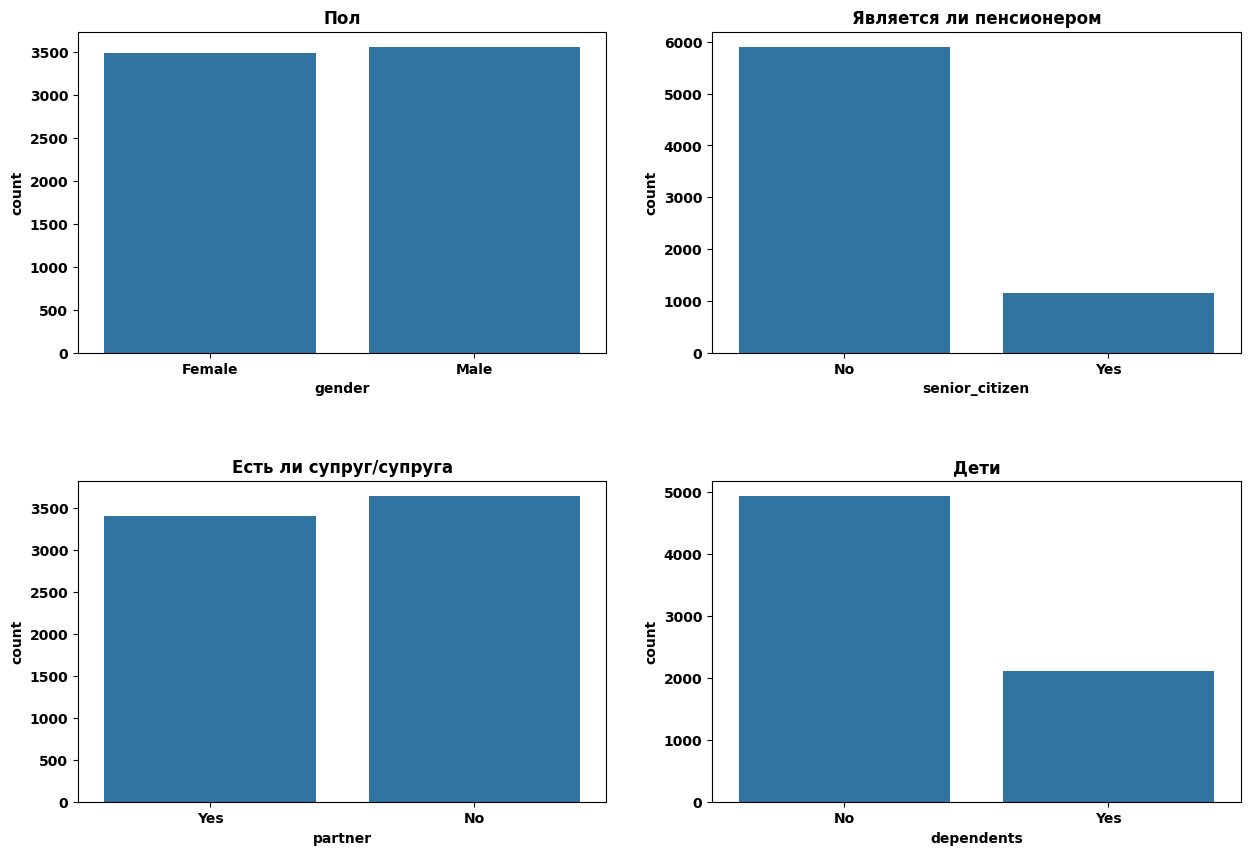

In [29]:
kat_df_2, axes = plt.subplots(2, 2, figsize=(15,10))
kat_df_2.subplots_adjust(hspace=0.4)

sns.countplot(data = df, x = 'gender', ax=axes[0, 0])
axes[0, 0].set_title('Пол')

sns.countplot(data = df, x = 'senior_citizen', ax=axes[0, 1])
axes[0, 1].set_title('Является ли пенсионером')

sns.countplot(data = df, x = 'partner', ax=axes[1, 0])
axes[1, 0].set_title('Есть ли супруг/супруга')

sns.countplot(data = df, x = 'dependents', ax=axes[1, 1])
axes[1, 1].set_title('Дети');

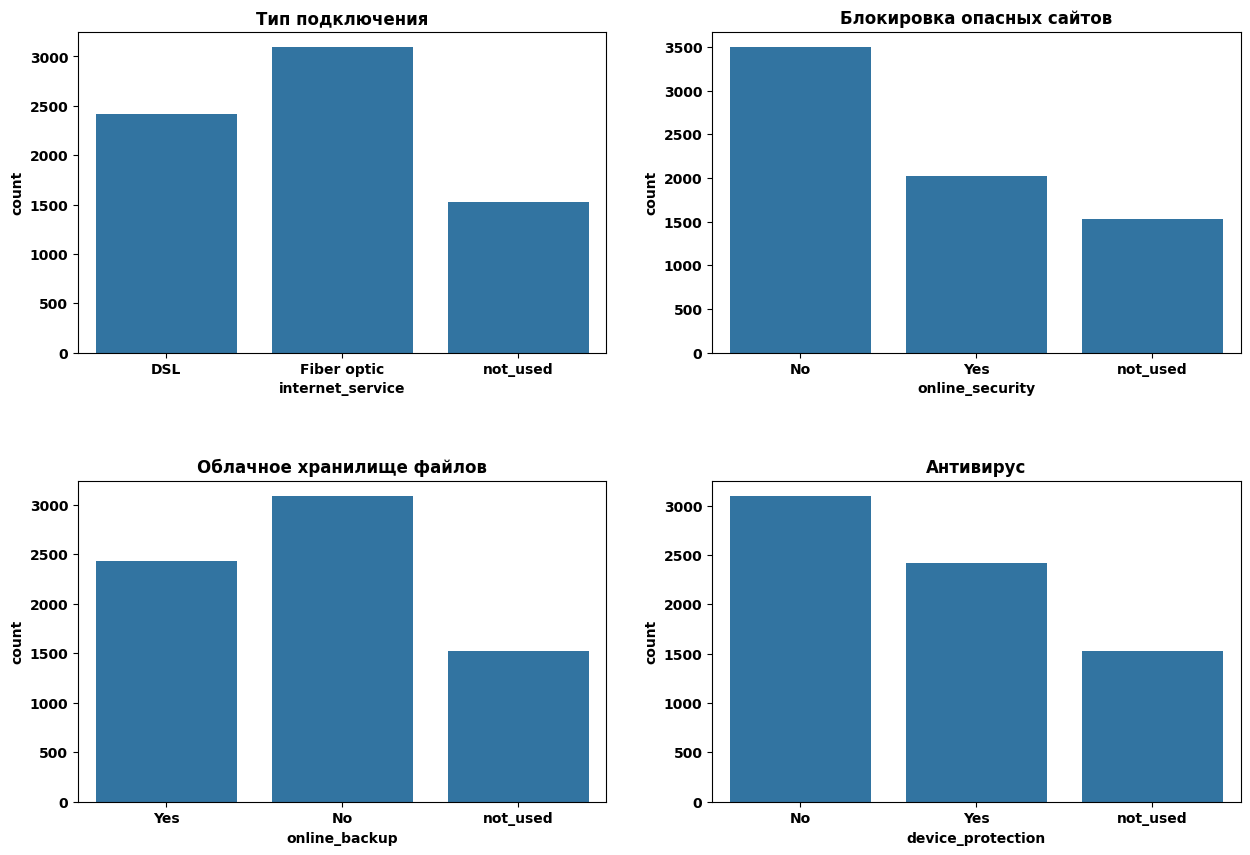

In [30]:
kat_df_3, axes = plt.subplots(2, 2, figsize=(15,10))
kat_df_3.subplots_adjust(hspace=0.4)

sns.countplot(data = df, x = 'internet_service', ax=axes[0, 0])
axes[0, 0].set_title('Тип подключения')

sns.countplot(data = df, x = 'online_security', ax=axes[0, 1])
axes[0, 1].set_title('Блокировка опасных сайтов')

sns.countplot(data = df, x = 'online_backup', ax=axes[1, 0])
axes[1, 0].set_title('Облачное хранилище файлов')

sns.countplot(data = df, x = 'device_protection', ax=axes[1, 1])
axes[1, 1].set_title('Антивирус');

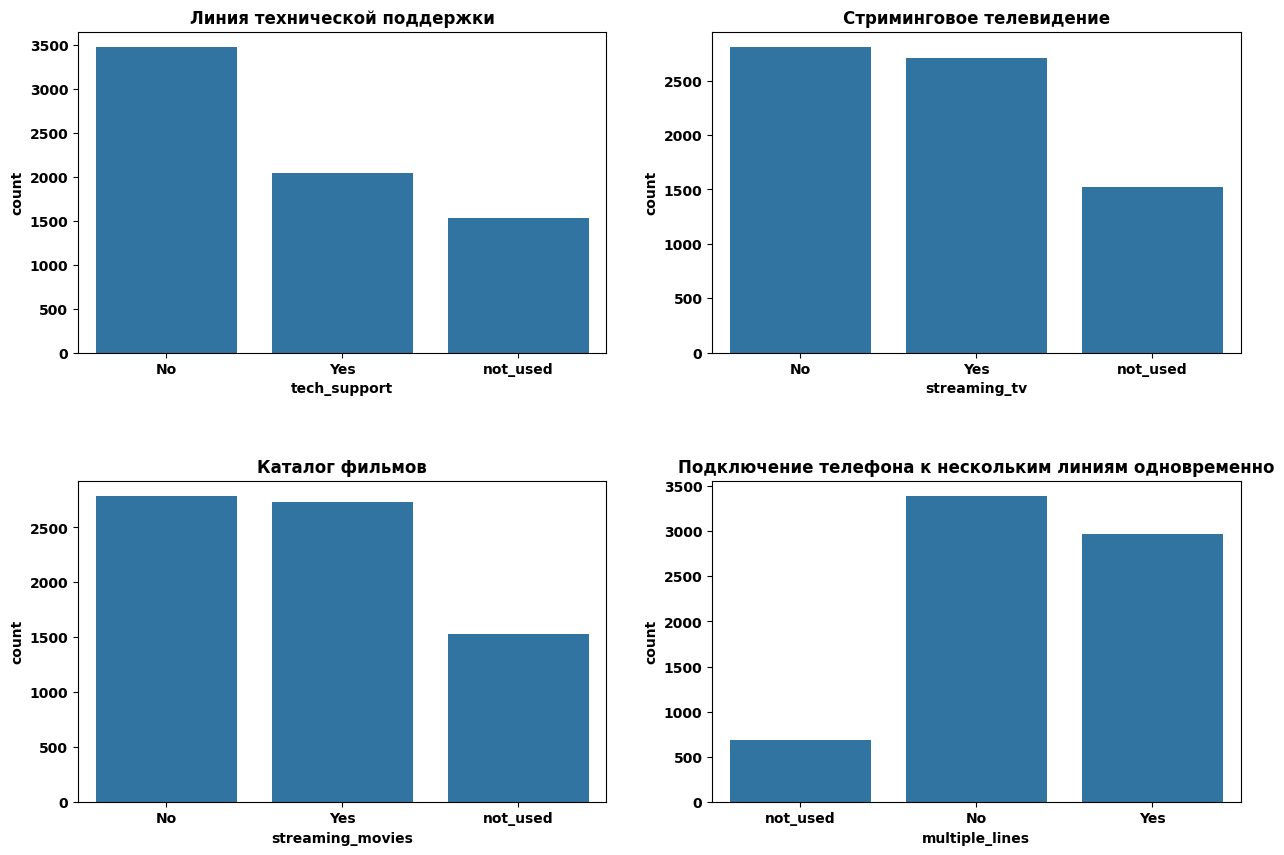

In [31]:
kat_df_4, axes = plt.subplots(2, 2, figsize=(15,10))
kat_df_4.subplots_adjust(hspace=0.4)

sns.countplot(data = df, x = 'tech_support', ax=axes[0, 0])
axes[0, 0].set_title('Линия технической поддержки')

sns.countplot(data = df, x = 'streaming_tv', ax=axes[0, 1])
axes[0, 1].set_title('Стриминговое телевидение')

sns.countplot(data = df, x = 'streaming_movies', ax=axes[1, 0])
axes[1, 0].set_title('Каталог фильмов')

sns.countplot(data = df, x = 'multiple_lines', ax=axes[1, 1])
axes[1, 1].set_title('Подключение телефона к нескольким линиям одновременно');

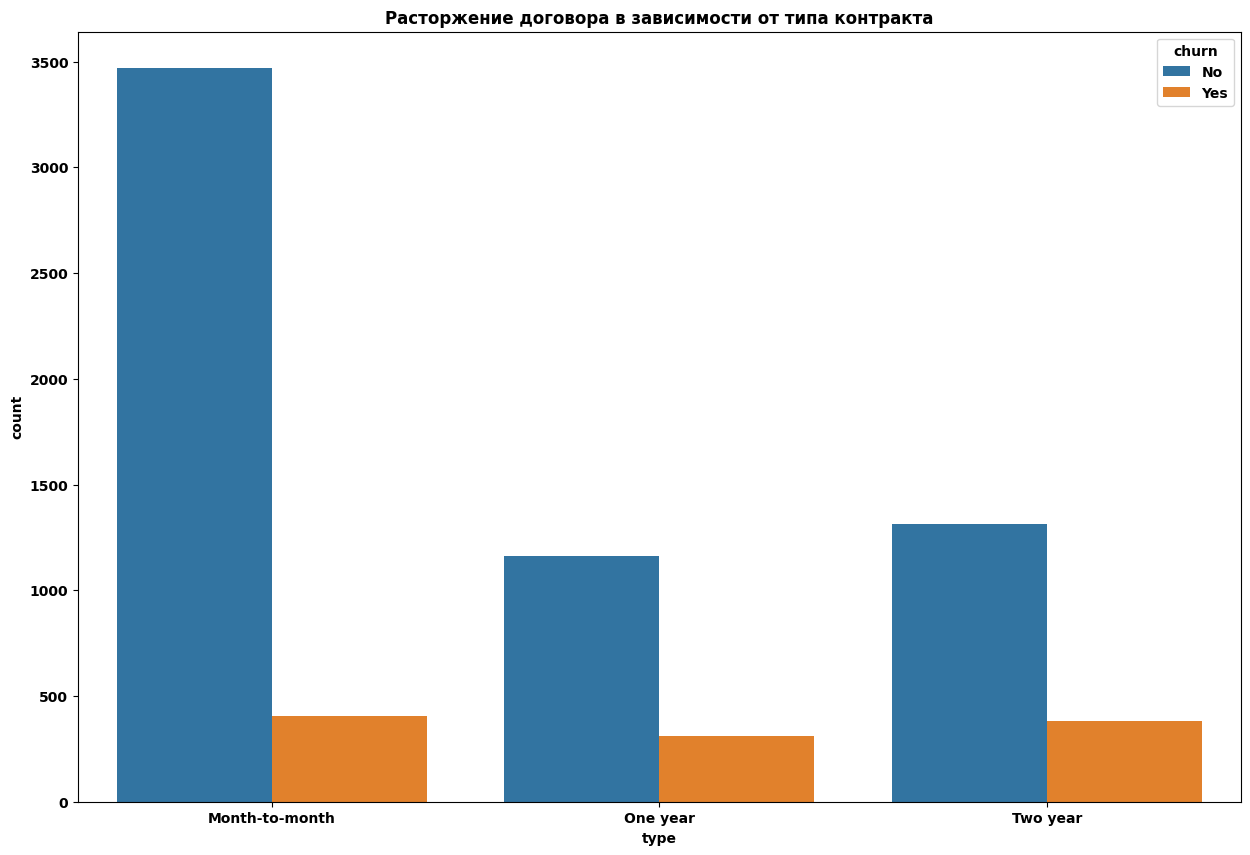

In [32]:
plt.figure(figsize=(15,10))
sns.countplot(data=df, x="type", hue="churn")
plt.title("Расторжение договора в зависимости от типа контракта");

примерно одинаково разрывают контракт клиент с различными типа оплаты

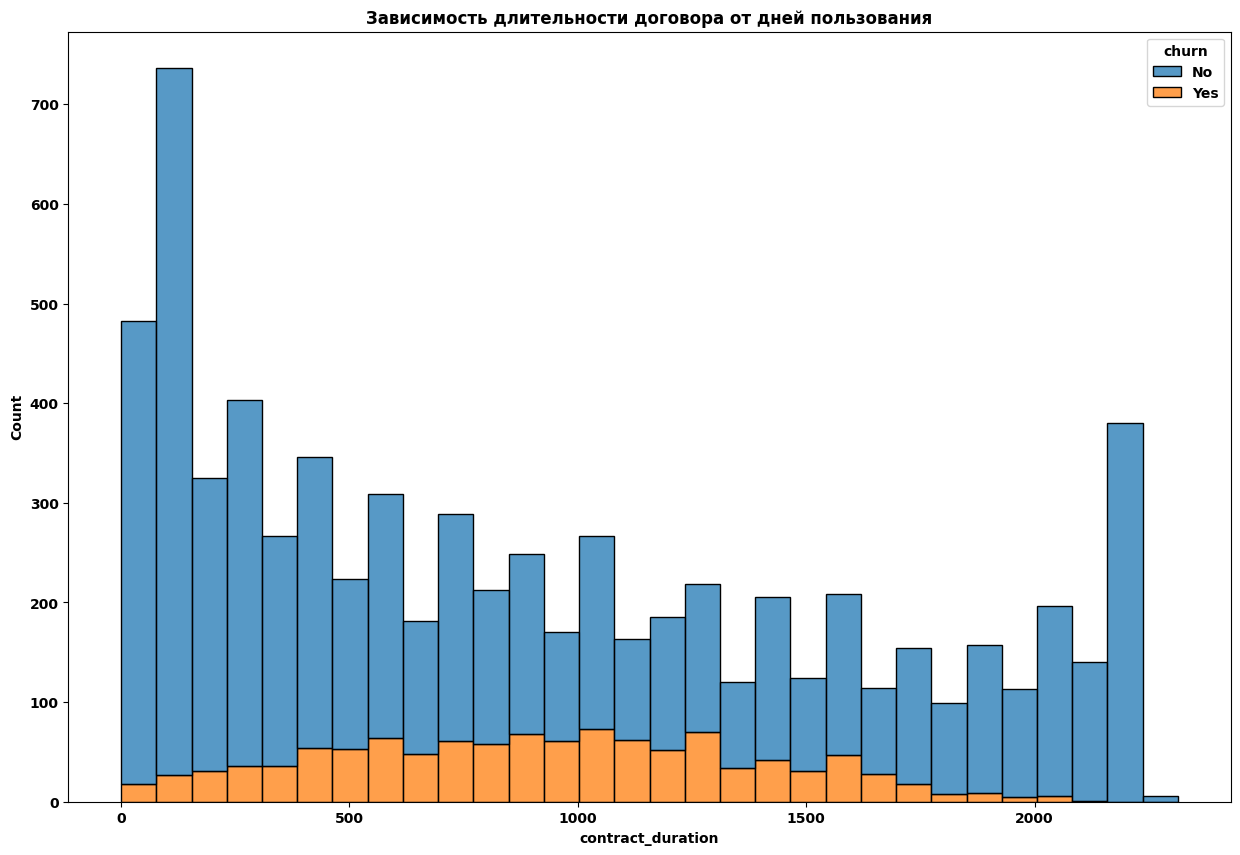

In [33]:
plt.figure(figsize=(15,10))
sns.histplot(data=df, x="contract_duration", hue="churn", multiple="stack", bins=30)
plt.title("Зависимость длительности договора от дней пользования");

По сроку действия договора видно, что разрывают чуть больше в промежуток между 300-1300 днями

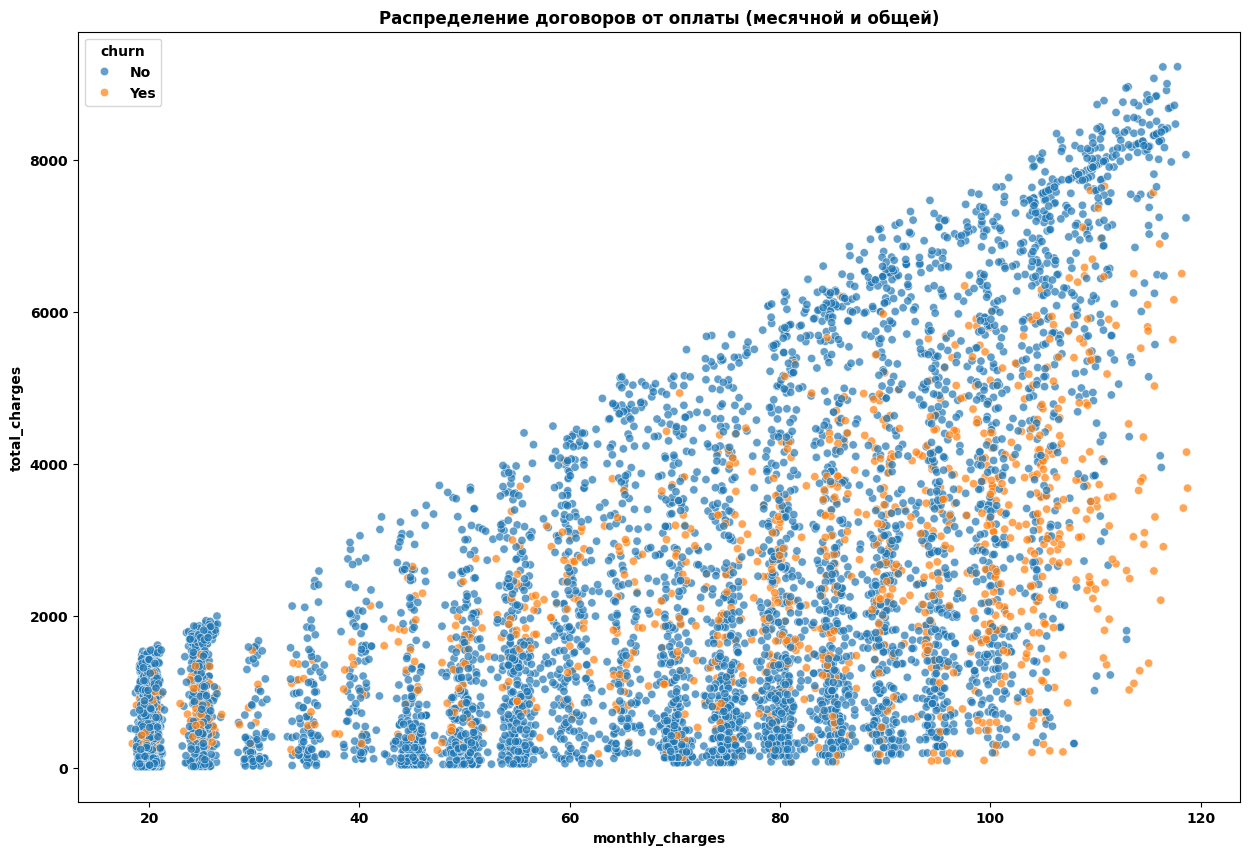

In [34]:
plt.figure(figsize=(15,10))
sns.scatterplot(data=df, x="monthly_charges", y="total_charges",hue="churn", alpha=0.7)
plt.title("Распределение договоров от оплаты (месячной и общей)");

Чем больше клиент платит ежемесячно, тем больше разрывов договора

Посмотрели на распеределения категориальнных признаков - всё в порядке, можно переходить к корреляционной матрице

,monthly_charges,total_charges,contract_duration
monthly_charges,1.000000,0.630448,0.220054
total_charges,0.630448,1.000000,0.821731
contract_duration,0.220054,0.821731,1.000000


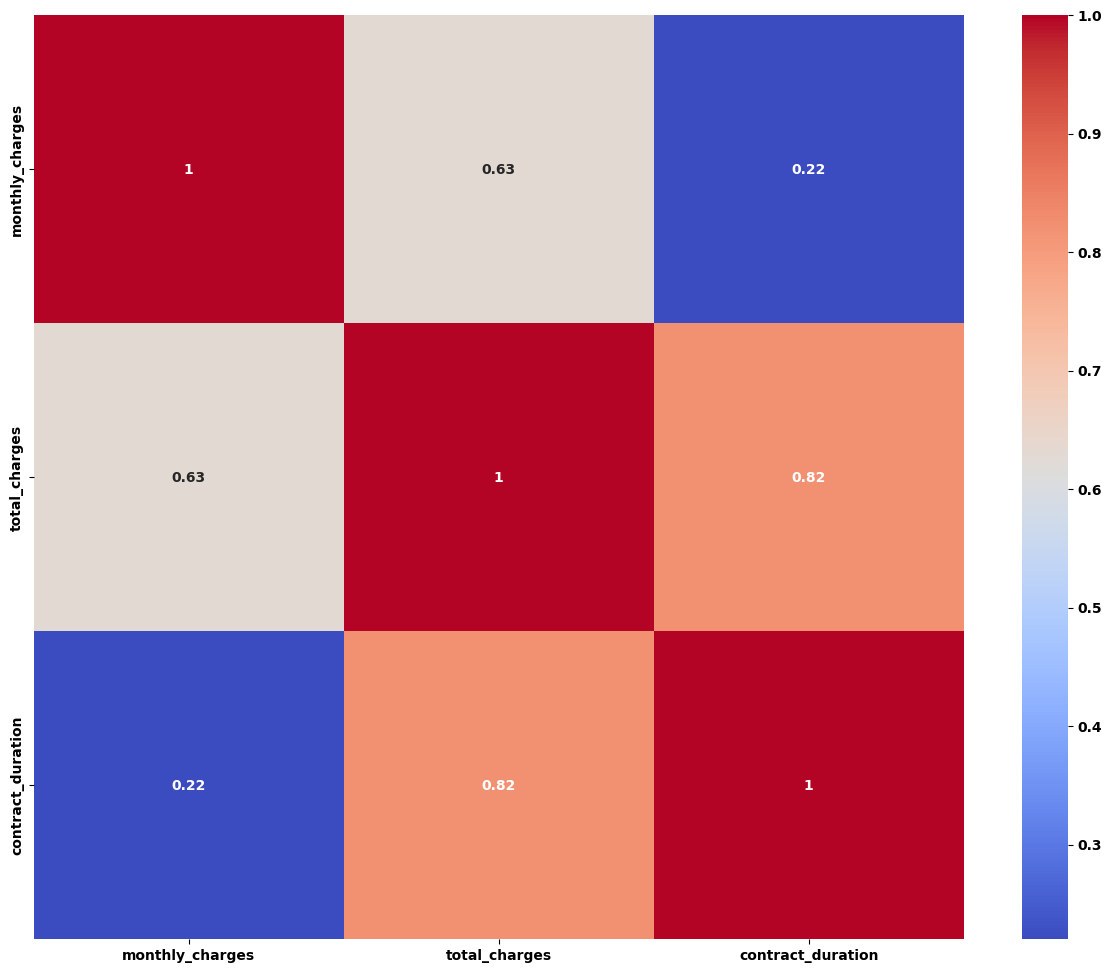

In [35]:
num_df = df.select_dtypes(include='number')
display(num_df.corr())

plt.figure(figsize=(15,12))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm');

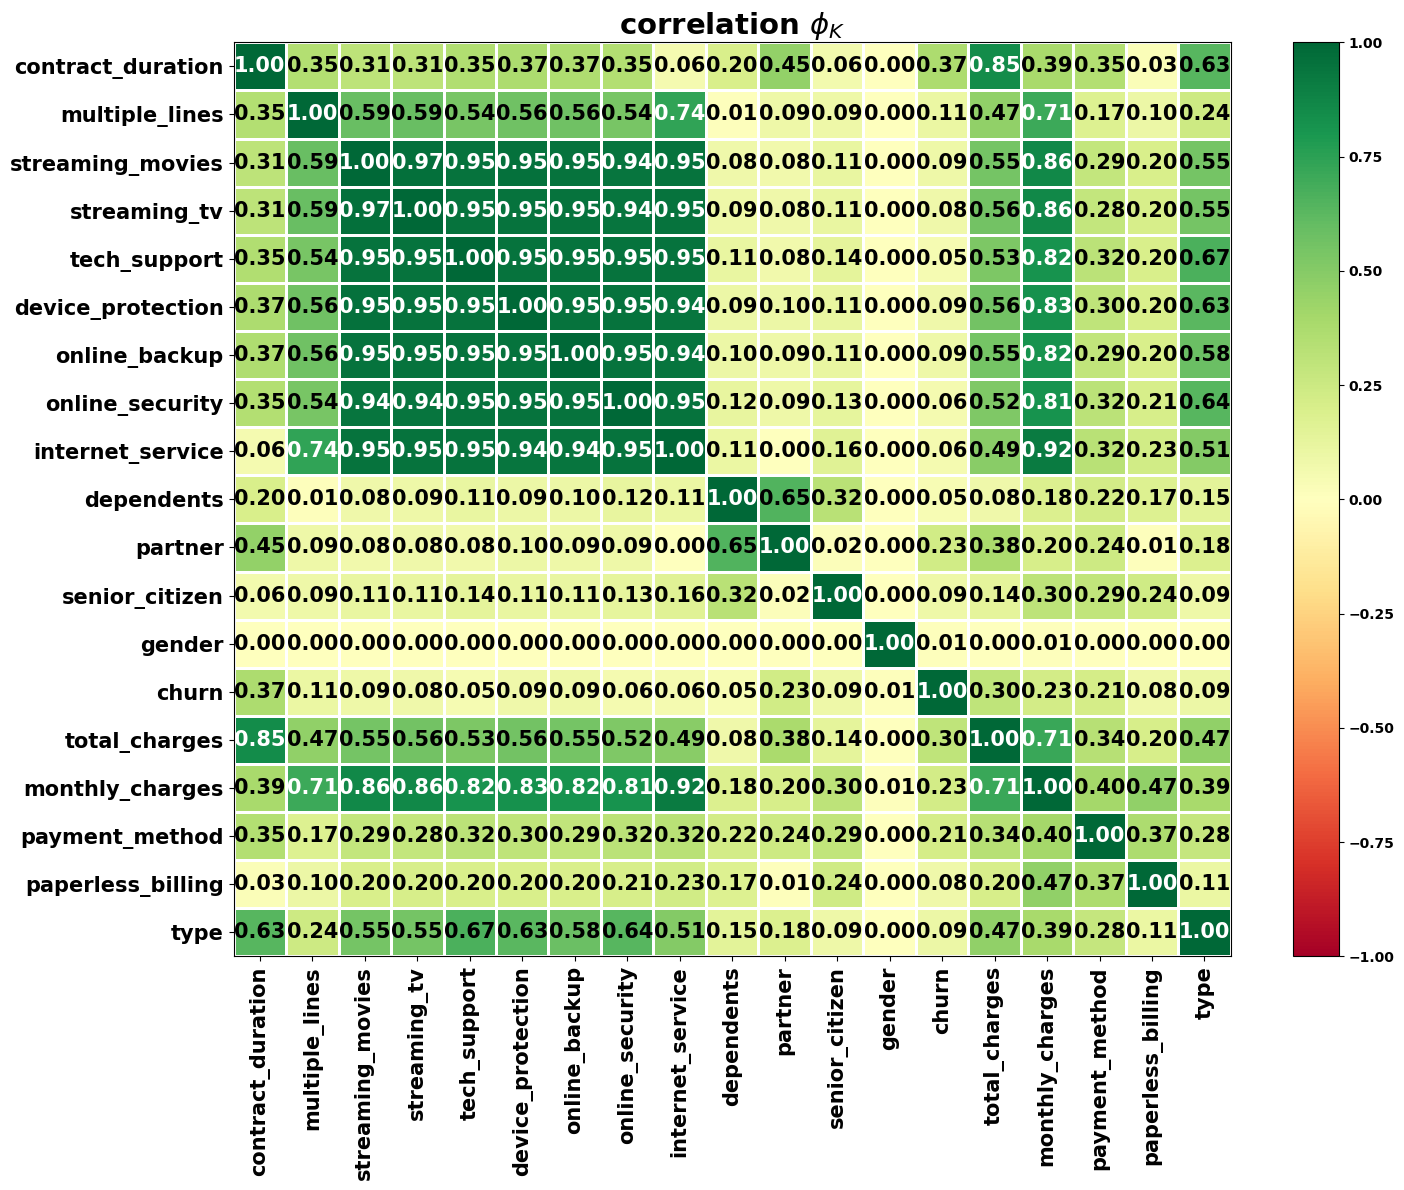

In [36]:
interval_cols = list(df.select_dtypes(include='number').columns)

phik_overview = df.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    title=r"correlation $\phi_K$",
    fontsize_factor=1.5,
    figsize=(15, 12)
)

Используя Матрицу phi_k посмотрели на силу зависимости между признаками. Можем заметить, что есть сильная зависимость между internet_service и любым из доп услуг при подключении интернета. Мы их полностью исключим из обучения, оставим только ключевой internet_service

**Выводы по разделу:**
- сделали дополнительный столбец contract_duration, в котором записали количество дней от начала действия договора до окончания (или же до даты анализа данных 01.02.2020, если он еще не прекращен)
- заполнили пропуски данным 'not_used', так как это не то же самое, что 'No'
- сразу убрали из объединенной таблицы 'begin_date', 'end_date', они нам не понадобятся
- сделали customer_id индексом
- посмотрели на распеределение признаков. Ничего неожиданного там нет

<a id="подготовка"></a> 
# 5. Подготовка данных

Еще раз посмотрим на данныe и подготовим их к обучению

In [37]:
df_model = df.copy()
df_model['churn'] = df_model['churn'].map({'No':0, 'Yes':1})

df_model.head(3)

,type,paperless_billing,payment_method,monthly_charges,total_charges,churn,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,contract_duration
customer_id,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,31.04,0,Female,No,Yes,No,DSL,No,Yes,No,No,No,No,not_used,31
5575-GNVDE,One year,No,Mailed check,56.95,2071.84,0,Male,No,No,No,DSL,Yes,No,Yes,No,No,No,No,1036
3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,226.17,0,Male,No,No,No,DSL,Yes,Yes,No,No,No,No,No,123


In [38]:
X = df_model.drop(['churn'], axis=1)
y = df_model['churn'].astype('int')

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

ohe_col = ['type', 'paperless_billing', 'payment_method', 'gender', 'senior_citizen', 'partner', 'dependents', \
              'internet_service', 'multiple_lines', 'online_security', 'online_backup', 'device_protection', 'tech_support', \
                  'streaming_tv', 'streaming_movies']
num_col = ['total_charges', 'monthly_charges', 'contract_duration']

**Выводы по разделу:**
- удалили ненужные столбцы для обучения
- подготовили признаки X и y (целевой - churn) для машинного обучения. Тренировочная и тестовая выборки 3:1
- подготовили колонки для мастабирования

<a id="обучение"></a> 
# 6. Обучение моделей машинного обучения

**В пайплайне используем две модели с различными гиперпараметрами - SVC и RandomForestClassifier**

In [39]:
ohe_pipe = Pipeline([
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])

data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_col),
        ('num', MinMaxScaler(), num_col)
    ], 
    remainder='passthrough') 

pipe_final= Pipeline([
        ('preprocessor', data_preprocessor),
        ('models', RandomForestClassifier(random_state=RANDOM_STATE))
    ])

param_grid = [{
        'models': [SVC(probability=True, random_state=RANDOM_STATE)],
        'models__C': [1, 1.1],
        'models__kernel': ['rbf'],
        'models__gamma': ['auto'],
        'models__class_weight': ['balanced'],
        'preprocessor__num': [StandardScaler()] 
    },
    {
    'models': [RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)],
    'models__n_estimators': [600, 650],
    'models__max_depth': [10, 11],
    'models__min_samples_leaf': [8],
    'models__class_weight': ['balanced'],
    'preprocessor__num': ['passthrough']
    }]

gs = GridSearchCV(
    pipe_final,
    param_grid,
    n_jobs=-1,
    cv=3,
    scoring='roc_auc',
)

gs.fit(X_train, y_train)

print('Лучшие параметры:', gs.best_params_)
print ('Метрика лучшей модели на тренировочной выборке:', round(gs.best_score_, 3))

Лучшие параметры: {'models': SVC(probability=True, random_state=151225), 'models__C': 1, 'models__class_weight': 'balanced', 'models__gamma': 'auto', 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}
Метрика лучшей модели на тренировочной выборке: 0.824


In [40]:
gs_df = pd.DataFrame(gs.cv_results_)[['rank_test_score', 'mean_test_score','params']] \
                .sort_values(by='rank_test_score').head(10)
gs_df

,rank_test_score,mean_test_score,params
0,1,0.823957,"{'models': SVC(probability=True, random_state=151225), 'models__C': 1, 'models__class_weight': 'balanced', 'models__gamma': 'auto', 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}"
1,2,0.823888,"{'models': SVC(probability=True, random_state=151225), 'models__C': 1.1, 'models__class_weight': 'balanced', 'models__gamma': 'auto', 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}"
2,3,0.817521,"{'models': RandomForestClassifier(n_jobs=-1, random_state=151225), 'models__class_weight': 'balanced', 'models__max_depth': 10, 'models__min_samples_leaf': 8, 'models__n_estimators': 600, 'preproc..."
3,4,0.817385,"{'models': RandomForestClassifier(n_jobs=-1, random_state=151225), 'models__class_weight': 'balanced', 'models__max_depth': 10, 'models__min_samples_leaf': 8, 'models__n_estimators': 650, 'preproc..."
4,5,0.817310,"{'models': RandomForestClassifier(n_jobs=-1, random_state=151225), 'models__class_weight': 'balanced', 'models__max_depth': 11, 'models__min_samples_leaf': 8, 'models__n_estimators': 600, 'preproc..."
5,6,0.817222,"{'models': RandomForestClassifier(n_jobs=-1, random_state=151225), 'models__class_weight': 'balanced', 'models__max_depth': 11, 'models__min_samples_leaf': 8, 'models__n_estimators': 650, 'preproc..."


**Третьей моделью возьмем Catboost. Ее не можем использовать в пайплайне, нам нужно обучать категориальные данные заново, без масштабирования заранее, так как Catboost отлично сам с этим справится.**

In [41]:
train_pool = Pool(X_train, y_train, cat_features=ohe_col)

param_dist = {
    'depth': range(5, 7),
    'learning_rate': [0.04],
    'iterations': range(500, 601),
    'l2_leaf_reg': range(6, 10)
}

param_list = list(ParameterSampler(param_dist, n_iter=5, random_state=RANDOM_STATE))

best_score = 0
best_params = None
results = []

for params in param_list:
    cb_params = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': RANDOM_STATE,
        'logging_level': 'Silent',
        'class_weights': [1, y_train.value_counts()[0] / y_train.value_counts()[1]],
        **params
    }

    cv_data = cv(
        pool=train_pool,
        params=cb_params,
        fold_count=3,
        stratified=True
    )
    
    mean_score = cv_data['test-AUC-mean'].values[-1]
    results.append({'params': params, 'mean_test_score': mean_score})
    
    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print("Лучшие параметры:", best_params)
print("ROC-AUC на кросс-валидации:", round(best_score, 3))

Лучшие параметры: {'learning_rate': 0.04, 'l2_leaf_reg': 7, 'iterations': 591, 'depth': 6}
ROC-AUC на кросс-валидации: 0.853


In [42]:
catboost_df = pd.DataFrame(results)
catboost_df['rank_test_score'] = catboost_df['mean_test_score'].rank(ascending=False)
catboost_df = catboost_df.sort_values('rank_test_score').head(10)

catboost_df

,params,mean_test_score,rank_test_score
2,"{'learning_rate': 0.04, 'l2_leaf_reg': 7, 'iterations': 591, 'depth': 6}",0.852556,1.0
0,"{'learning_rate': 0.04, 'l2_leaf_reg': 8, 'iterations': 565, 'depth': 6}",0.851760,2.0
1,"{'learning_rate': 0.04, 'l2_leaf_reg': 7, 'iterations': 535, 'depth': 5}",0.849438,3.0
4,"{'learning_rate': 0.04, 'l2_leaf_reg': 9, 'iterations': 590, 'depth': 6}",0.848729,4.0
3,"{'learning_rate': 0.04, 'l2_leaf_reg': 9, 'iterations': 549, 'depth': 6}",0.846980,5.0


Посмотрим на распеределение признаков, оказывающих наибольшее влияение на обучение модели.

In [43]:
best_cb = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    logging_level='Silent',
    class_weights=[1, y_train.value_counts()[0] / y_train.value_counts()[1]],
    **best_params
)

best_cb.fit(X_train, y_train, cat_features=ohe_col)

feature_importance = best_cb.get_feature_importance()
imp = pd.Series(feature_importance, index=X_train.columns).sort_values(ascending=False)

print(imp.head(10))

contract_duration    39.079416
type                 11.117076
total_charges         9.901943
monthly_charges       6.209244
payment_method        5.970911
multiple_lines        5.221199
partner               3.868682
online_backup         3.705300
device_protection     2.418548
streaming_movies      2.154717
dtype: float64


**Выводы по разделу:**
- 3 модели обучения использовали для решение задачи классификации по оттоку клиентов - SVC, RandomForestClassifier и Catboost
- Первые две модели завернули в пайплайн. Результат лучший у SVC - 0.824
- Catboost обучили отдельно с RandomizedSearchCV. Результат - 0.853
- Наиболее оказывающие влияние признаки - длительность контракта и тип контракта

<a id="выбор"></a> 
# 7. Выбор лучшей модели

По результатам проверки лучшей моделью стала Catboost. Проверим на тестовой выборке:

In [44]:
y_test_pred = best_cb.predict_proba(X_test)[:,1]
print('ROC-AUC на тестовой выборке:', round(roc_auc_score(y_test, y_test_pred), 3))

y_pred_class = best_cb.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred_class), 3))

ROC-AUC на тестовой выборке: 0.881
Accuracy: 0.811


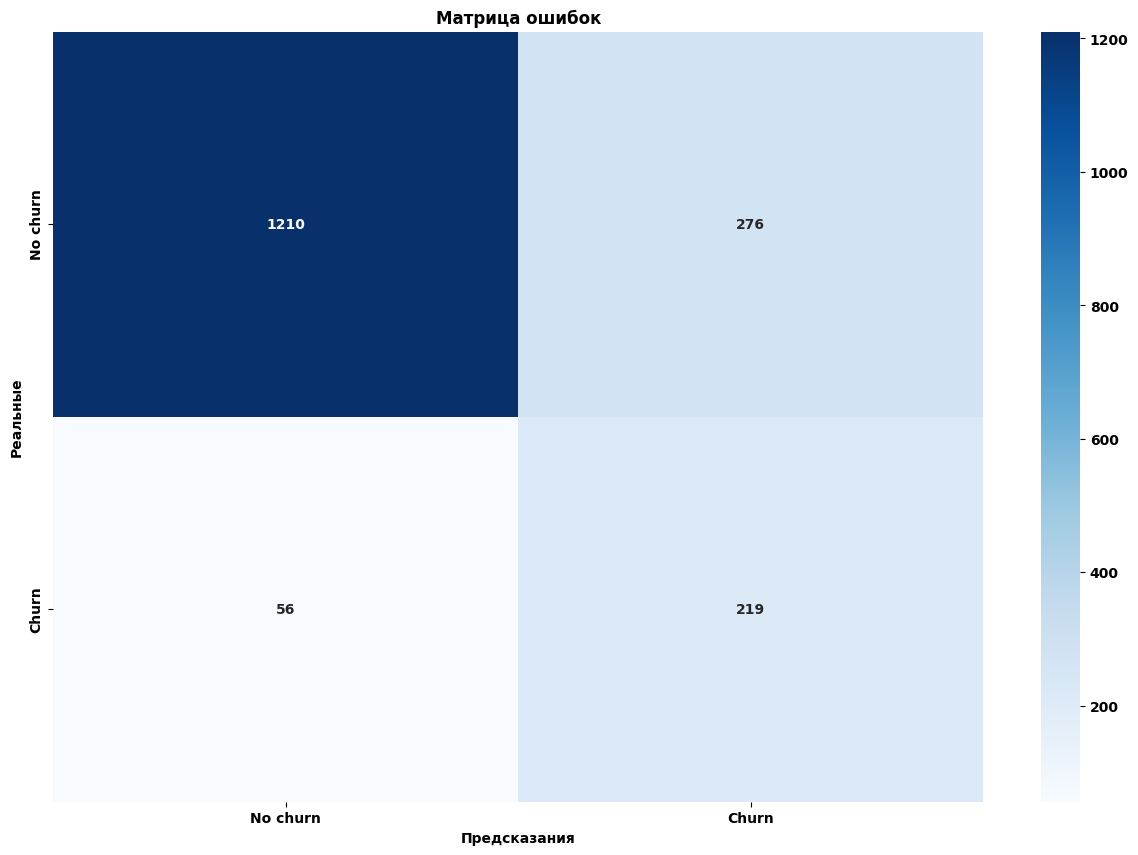

In [45]:
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No churn', 'Churn'],
            yticklabels=['No churn', 'Churn'])
plt.title('Матрица ошибок')
plt.ylabel('Реальные')
plt.xlabel('Предсказания');

In [46]:
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)       

print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))

Precision: 0.442
Recall: 0.796


**Результат Catboost ROC_AUC на тестовой выборке: 0.881.** В 88,1% модель присвоит более высокую вероятность ухода клиенту, который реально уйдет.  
**Результат Accuracy - 0.811.** В 81,1% случаев модель классифицировала клиентов (и уходящих, и остающихся) правильно.  
**Precision = 0.442.** В 44,2% случаев, когда модель предсказала уходящих клиентов, клиенты реально ушли  
**Recall = 0.796.** В 79,6% случаев модель правильно предсказала уходящих клиентов

<a id="вывод"></a> 
# 8. Общий вывод и рекомендации заказчику

1) Были загружены 4 датасета с данными по клиентам и договорам по телекоммуникаям (интернет + телефония) Оператора связи «ТелеДом». В датасетах 5-7 строк в каждом  
2) Была проведена предобработка данных - изменен тип данных, заполнены пропуски, убран верхний регистр. Столбцы с датами убраны, место них добавлено количество месяцев. Добавлен столбец churn, который и будет целевым признаком  
3) Объединили все столбцы по ключу customer_id. Там, где появились пропуски, мы заполнили значением not_used. Это не равносильно 'No', поэтому добавляем третий вариант во все строчки  
4) По итогам просмотра распределений видим, что много клиентов расторгают договор, кто много платит в месяц. Так же видим, что многие расторгают договор в период 300-1300 дней   
5) Признак churn выделяем как целевой, остальные столбцы масштабируем  
6) 3 модели обучения - SVC, RandomForestClassifier и Catboost. По итогам лучшей моделью становится Catboost. ROC-AUC 0.853  
7) **Результат Catboost ROC_AUC на тестовой выборке: 0.881.** В 88,1% модель присвоит более высокую вероятность ухода клиенту, который реально уйдет.  
**Результат Accuracy - 0.811.** В 81,1% случаев модель классифицировала клиентов (и уходящих, и остающихся) правильно.  
**Precision = 0.442.** В 44,2% случаев, когда модель предсказала уходящих клиентов, клиенты реально ушли  
**Recall = 0.796.** В 79,6% случаев модель правильно предсказала уходящих клиентов  
8) Клиенту посоветуем обращать внимание на срок договора, тип договора, и на сумму, которую клиент платит - чем она выше, тем больше шансов, что клиент "сбежит"  